#  NLP Final Project — English News Text Summarization Using Multilingual T5 (mT5) Transformer
## Menggunakan Arsitektur mT5 (Multilingual T5 Transformer)

**Kelompok:**
- Alexander — Data & Preprocessing
- Marcellino — Arsitektur & Training
- Nicolas — Evaluasi & Kesimpulan

---

###  Deskripsi Proyek
Proyek ini membangun sistem **Text Summarization** (Peringkas Teks) untuk berita Inggris menggunakan model **mT5 (Multilingual T5)**, sebuah arsitektur Transformer encoder-decoder yang powerful untuk tugas sequence-to-sequence.

**Pipeline Utama:**
1. Load & eksplorasi dataset berita Inggris
2. Preprocessing & tokenisasi (Subword BPE via SentencePiece)
3. Fine-tuning mT5-small pada dataset kustom
4. Evaluasi menggunakan ROUGE score
5. Demo inferensi sistem

---
##  BAGIAN ALEXANDER — Instalasi, Data & Preprocessing

### Cell 1: Instalasi Library

In [ ]:
# ============================================================
# CELL 1 — INSTALASI LIBRARY
# Dikerjakan oleh: Alexander
# ============================================================
import subprocess, sys
subprocess.run([
    sys.executable, '-m', 'pip', 'install',
    'transformers', 'datasets', 'rouge-score', 'sentencepiece', 'accelerate', '-q'
], check=True)

print(' Semua library berhasil diinstall!')


 Semua library berhasil diinstall!


### Cell 2: Import Library & Konfigurasi

In [2]:
# ============================================================
# CELL 2 — IMPORT LIBRARY & KONFIGURASI GLOBAL
# Dikerjakan oleh: Alexander
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
    pipeline
)
from datasets import Dataset, DatasetDict
from rouge_score import rouge_scorer

warnings.filterwarnings('ignore')

# ─── Konfigurasi Global ───────────────────────────────────────
MODEL_CHECKPOINT  = 'google/mt5-small'
MAX_INPUT_LENGTH  = 512
MAX_TARGET_LENGTH = 128
BATCH_SIZE        = 16
EPOCHS            = 3
LEARNING_RATE     = 5e-5
SEED              = 42

# Cek ketersediaan GPU
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'  Device yang digunakan: {DEVICE}')
if DEVICE == 'cuda':
    print(f'    GPU: {torch.cuda.get_device_name(0)}')
    print(f'    VRAM tersedia: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'  Model  : {MODEL_CHECKPOINT}')
print(f'  Epochs : {EPOCHS}')
print(f'  Batch  : {BATCH_SIZE}')

  Device yang digunakan: cuda
    GPU: NVIDIA GeForce RTX 4050 Laptop GPU
    VRAM tersedia: 6.4 GB
  Model  : google/mt5-small
  Epochs : 3
  Batch  : 16


### Cell 3: Load Dataset

In [3]:
# ============================================================
# CELL 3 — LOAD DATASET
# Dikerjakan oleh: Alexander
# ============================================================
import os
import pandas as pd

df1 = pd.read_csv('news_summary.csv',      encoding='latin-1')
df2 = pd.read_csv('news_summary_more.csv', encoding='latin-1')

df1 = df1[['text', 'headlines']].copy()
df2 = df2[['text', 'headlines']].copy()

df = pd.concat([df1, df2], ignore_index=True)
df = df.rename(columns={'text': 'article', 'headlines': 'summary'})

df = df.dropna(subset=['article', 'summary']).reset_index(drop=True)
df = df[df['article'].str.len() > 50].reset_index(drop=True)
df = df.sample(n=15000, random_state=SEED).reset_index(drop=True)

print(f' Dataset berhasil dimuat!')
print(f'   Jumlah sampel : {len(df)}')
print(f'   Kolom         : {list(df.columns)}')
print()
print('--- Contoh artikel ---')
print(df["article"].iloc[0])
print()
print('--- Contoh ringkasan ---')
print(df["summary"].iloc[0])

 Dataset berhasil dimuat!
   Jumlah sampel : 15000
   Kolom         : ['article', 'summary']

--- Contoh artikel ---
Fraud-accused jeweller Nirav Modi is currently in London on a Singaporean passport while his brother Nishal Modi is in Antwerp on a Belgian passport, according to reports. Earlier, Nirav Modi had refused to return to India for investigation citing "businesses abroad". Nirav's sister Purvi Mehta also holds a Belgian passport and is reportedly in Hong Kong at present.

--- Contoh ringkasan ---
Nirav Modi in London on Singaporean passport: Reports


### Cell 4: Eksplorasi & Analisis Dataset (EDA)

 STATISTIK DESKRIPTIF DATASET
       article_len_words  summary_len_words  compression_ratio
count       15000.000000       15000.000000       15000.000000
mean           58.295267           9.549933           0.163943
std             2.335133           1.453105           0.024915
min            41.000000           4.000000           0.067000
25%            57.000000           9.000000           0.150000
50%            59.000000          10.000000           0.167000
75%            60.000000          10.000000           0.183000
max            64.000000          16.000000           0.291000


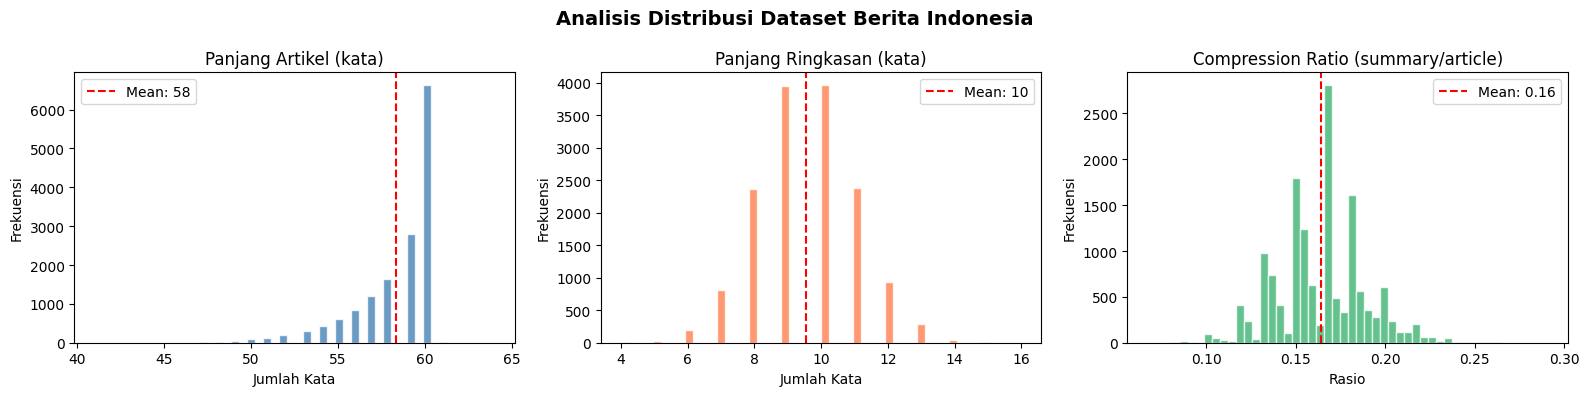


 Grafik EDA disimpan sebagai eda_distribusi.png


In [4]:
# ============================================================
# CELL 4 — EXPLORATORY DATA ANALYSIS (EDA)
# Dikerjakan oleh: Alexander
# ============================================================

# Hitung panjang teks (dalam karakter dan kata)
df['article_len_chars'] = df['article'].apply(len)
df['summary_len_chars'] = df['summary'].apply(len)
df['article_len_words'] = df['article'].apply(lambda x: len(x.split()))
df['summary_len_words'] = df['summary'].apply(lambda x: len(x.split()))
df['compression_ratio']  = (df['summary_len_words'] / df['article_len_words']).round(3)

# Statistik deskriptif
print('=' * 55)
print(' STATISTIK DESKRIPTIF DATASET')
print('=' * 55)
stats = df[['article_len_words', 'summary_len_words', 'compression_ratio']].describe()
print(stats.to_string())

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Analisis Distribusi Dataset Berita Indonesia', fontsize=14, fontweight='bold')

# Plot 1: Distribusi panjang artikel
axes[0].hist(df['article_len_words'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Panjang Artikel (kata)')
axes[0].set_xlabel('Jumlah Kata')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(df['article_len_words'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["article_len_words"].mean():.0f}')
axes[0].legend()

# Plot 2: Distribusi panjang ringkasan
axes[1].hist(df['summary_len_words'], bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title('Panjang Ringkasan (kata)')
axes[1].set_xlabel('Jumlah Kata')
axes[1].set_ylabel('Frekuensi')
axes[1].axvline(df['summary_len_words'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["summary_len_words"].mean():.0f}')
axes[1].legend()

# Plot 3: Compression ratio
axes[2].hist(df['compression_ratio'], bins=50, color='mediumseagreen', edgecolor='white', alpha=0.8)
axes[2].set_title('Compression Ratio (summary/article)')
axes[2].set_xlabel('Rasio')
axes[2].set_ylabel('Frekuensi')
axes[2].axvline(df['compression_ratio'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["compression_ratio"].mean():.2f}')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_distribusi.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n Grafik EDA disimpan sebagai eda_distribusi.png')

### Cell 5: Preprocessing & Tokenisasi

In [ ]:
# ============================================================
# CELL 5 — PREPROCESSING & TOKENISASI (Subword BPE)
# Dikerjakan oleh: Alexander
# ============================================================

print(' Memuat tokenizer mT5...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
print(f' Tokenizer berhasil dimuat!')
print(f'   Ukuran Vocabulary: {tokenizer.vocab_size:,} token')
print(f'   Tipe: SentencePiece (Subword Unigram LM)')

# ─── Demonstrasi Tokenisasi ──────────────────────────────────
contoh_kalimat = 'The government announced a new policy on climate change affecting major industries.'  
tokens    = tokenizer.tokenize(contoh_kalimat)
token_ids = tokenizer.encode(contoh_kalimat)

print('\n' + '─' * 55)
print(' DEMONSTRASI TOKENISASI SUBWORD')
print('─' * 55)
print(f'Kalimat asli  : {contoh_kalimat}')
print(f'Token subword : {tokens}')
print(f'Token IDs     : {token_ids}')
print(f'Jumlah token  : {len(tokens)}')
print(f'Jumlah kata   : {len(contoh_kalimat.split())}')
print(f'\n Perhatikan "▁" = spasi awal kata (SentencePiece convention)')
print(f'   Kata jarang akan dipecah menjadi subword lebih kecil')

# ─── Fungsi Preprocessing ────────────────────────────────────
def preprocess_function(examples):
    prefix = 'summarize: '
    inputs = [prefix + article for article in examples['article']]

    # Tokenisasi input (artikel)
    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding='max_length'
    )

    #  Tokenisasi target tanpa as_target_tokenizer (deprecated)
    labels = tokenizer(
        text_target=examples['summary'],
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
        padding='max_length'
    )

    # Ganti padding token ID dengan -100 agar tidak dihitung dalam loss
    label_ids = labels['input_ids']
    label_ids = [
        [(l if l != tokenizer.pad_token_id else -100) for l in label]
        for label in label_ids
    ]
    model_inputs['labels'] = label_ids
    return model_inputs

print('\n Fungsi preprocessing telah didefinisikan!')
print(f'   MAX_INPUT_LENGTH  = {MAX_INPUT_LENGTH} token')
print(f'   MAX_TARGET_LENGTH = {MAX_TARGET_LENGTH} token')
print(f'   Task prefix       = "summarize: "')

 Memuat tokenizer mT5...


 Tokenizer berhasil dimuat!
   Ukuran Vocabulary: 250,100 token
   Tipe: SentencePiece (Subword Unigram LM)

───────────────────────────────────────────────────────
 DEMONSTRASI TOKENISASI SUBWORD
───────────────────────────────────────────────────────
Kalimat asli  : The government announced a new policy on climate change affecting major industries.
Token subword : ['▁The', '▁government', '▁', 'announced', '▁', 'a', '▁new', '▁policy', '▁on', '▁', 'climate', '▁change', '▁affect', 'ing', '▁major', '▁', 'industries', '.']
Token IDs     : [486, 13749, 259, 50496, 259, 262, 1546, 22815, 351, 259, 33674, 6313, 22220, 347, 9677, 259, 90079, 260, 1]
Jumlah token  : 18
Jumlah kata   : 12

 Perhatikan "▁" = spasi awal kata (SentencePiece convention)
   Kata jarang akan dipecah menjadi subword lebih kecil

 Fungsi preprocessing telah didefinisikan!
   MAX_INPUT_LENGTH  = 512 token
   MAX_TARGET_LENGTH = 128 token
   Task prefix       = "summarize: "


### Cell 6: Membuat Dataset Split

In [ ]:
# ============================================================
# CELL 6 — SPLIT DATASET & APPLY TOKENIZATION (FIXED)
# ============================================================

np.random.seed(SEED)

n         = len(df)
indices   = np.random.permutation(n)
train_end = int(0.70 * n)
val_end   = int(0.85 * n)

df_train = df.iloc[indices[:train_end]].reset_index(drop=True)
df_val   = df.iloc[indices[train_end:val_end]].reset_index(drop=True)
df_test  = df.iloc[indices[val_end:]].reset_index(drop=True)

print(f' Split dataset (70/15/15):')
print(f'   Train      : {len(df_train)} sampel')
print(f'   Validation : {len(df_val)} sampel')
print(f'   Test       : {len(df_test)} sampel')

def tokenize_function(examples):
    prefix = 'summarize: '
    inputs = [prefix + art for art in examples['article']]

    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding=False
    )

    labels = tokenizer(
        text_target=examples['summary'],  # 
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
        padding=False
    )

    label_ids = [
        [(token if token != tokenizer.pad_token_id else -100) for token in label]
        for label in labels['input_ids']
    ]
    model_inputs['labels'] = label_ids
    return model_inputs

from datasets import Dataset as HFDataset, DatasetDict

raw_datasets = DatasetDict({
    'train'     : HFDataset.from_pandas(df_train),
    'validation': HFDataset.from_pandas(df_val),
    'test'      : HFDataset.from_pandas(df_test),
})

tokenized_datasets = raw_datasets.map(
    tokenize_function,
    batched=True,
    remove_columns=raw_datasets['train'].column_names,  
)

print()
print(f' Tokenisasi selesai!')
print(f'   Fitur: {list(tokenized_datasets["train"].features.keys())}')

sample = tokenized_datasets['train'][0]
labels = sample['labels']
valid_tokens = sum(1 for t in labels if t != -100)
print(f'\n Verifikasi label:')
print(f'   Total token label : {len(labels)}')
print(f'   Token valid       : {valid_tokens}')
print(f'   Token -100        : {len(labels) - valid_tokens}')
print(f'   Preview           : {labels[:10]}')

 Split dataset (70/15/15):
   Train      : 10500 sampel
   Validation : 2250 sampel
   Test       : 2250 sampel


Map:   0%|          | 0/10500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2250 [00:00<?, ? examples/s]

Map:   0%|          | 0/2250 [00:00<?, ? examples/s]


 Tokenisasi selesai!
   Fitur: ['input_ids', 'attention_mask', 'labels']

 Verifikasi label:
   Total token label : 18
   Token valid       : 18
   Token -100        : 0
   Preview           : [28561, 34245, 584, 58701, 48043, 6866, 210562, 400, 73102, 527]


---
##  BAGIAN MARCELLINO — Arsitektur Model & Training

### Cell 7: Load Model & Visualisasi Arsitektur

In [7]:
# ============================================================
# CELL 7 — LOAD MODEL mT5 & ANALISIS ARSITEKTUR
# Dikerjakan oleh: Marcellino
# ============================================================

print(' Memuat model mT5-small...')
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_CHECKPOINT)
print(' Model berhasil dimuat!')

# Hitung jumlah parameter
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print('\n' + '=' * 55)
print('  ARSITEKTUR MODEL: mT5-small')
print('=' * 55)
print(f'   Total Parameter    : {total_params:,}')
print(f'   Trainable Parameter: {trainable_params:,}')
print(f'   Model Config       :')
print(f'     - d_model (hidden size): {model.config.d_model}')
print(f'     - num_heads (attention) : {model.config.num_heads}')
print(f'     - num_layers (encoder)  : {model.config.num_layers}')
print(f'     - num_decoder_layers    : {model.config.num_decoder_layers}')
print(f'     - d_ff (feed-forward)   : {model.config.d_ff}')
print(f'     - vocab_size            : {model.config.vocab_size:,}')

print('\n JUSTIFIKASI PEMILIHAN mT5:')
print('   ✓ Mendukung Bahasa Indonesia secara native (101 bahasa)')
print('   ✓ Arsitektur encoder-decoder ideal untuk seq2seq')
print('   ✓ Pre-trained pada mC4 corpus yang mencakup web Indonesia')
print('   ✓ Versi -small cocok untuk fine-tuning di Colab T4 (16GB VRAM)')
print('   ✓ Relative Attention Bias — lebih baik menangkap posisi token')

 Memuat model mT5-small...


Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


 Model berhasil dimuat!

  ARSITEKTUR MODEL: mT5-small
   Total Parameter    : 300,176,768
   Trainable Parameter: 300,176,768
   Model Config       :
     - d_model (hidden size): 512
     - num_heads (attention) : 6
     - num_layers (encoder)  : 8
     - num_decoder_layers    : 8
     - d_ff (feed-forward)   : 1024
     - vocab_size            : 250,112

 JUSTIFIKASI PEMILIHAN mT5:
   ✓ Mendukung Bahasa Indonesia secara native (101 bahasa)
   ✓ Arsitektur encoder-decoder ideal untuk seq2seq
   ✓ Pre-trained pada mC4 corpus yang mencakup web Indonesia
   ✓ Versi -small cocok untuk fine-tuning di Colab T4 (16GB VRAM)
   ✓ Relative Attention Bias — lebih baik menangkap posisi token


### Cell 8: Konfigurasi Training

In [8]:
# ============================================================
# CELL 8 — KONFIGURASI TRAINING ARGUMENTS
# Dikerjakan oleh: Marcellino
# ============================================================

data_collator = DataCollatorForSeq2Seq(
    tokenizer,
    model=model,
    label_pad_token_id=-100,
    pad_to_multiple_of=8
)

training_args = Seq2SeqTrainingArguments(
    output_dir                  = './results',
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    learning_rate               = LEARNING_RATE,
    weight_decay                = 0.01,
    warmup_ratio                = 0.1,         #  Lebih adaptif dari warmup_steps
    predict_with_generate       = True,
    generation_max_length       = 128,         #  Batasi panjang output generasi
    eval_strategy               = 'epoch',     #  Ganti dari evaluation_strategy
    save_strategy               = 'epoch',
    save_total_limit            = 2,           #  Hemat disk, simpan 2 checkpoint terbaik
    load_best_model_at_end      = True,
    metric_for_best_model       = 'eval_loss',
    greater_is_better           = False,       #  Loss lebih kecil = lebih baik
    logging_dir                 = './logs',
    logging_steps               = 5,
    fp16                        = False,
    seed                        = SEED,
    report_to                   = 'none'
)

print(' Training Arguments dikonfigurasi:')
print(f'   Epochs          : {training_args.num_train_epochs}')
print(f'   Learning rate   : {training_args.learning_rate}')
print(f'   Batch size      : {training_args.per_device_train_batch_size}')
print(f'   Weight decay    : {training_args.weight_decay}')
print(f'   Warmup ratio    : {training_args.warmup_ratio}')
print(f'   FP16 (mixed)    : {training_args.fp16}')
print(f'   Output dir      : {training_args.output_dir}')
print(f'   Save limit      : {training_args.save_total_limit}')

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


 Training Arguments dikonfigurasi:
   Epochs          : 3
   Learning rate   : 5e-05
   Batch size      : 16
   Weight decay    : 0.01
   Warmup ratio    : 0.1
   FP16 (mixed)    : False
   Output dir      : ./results
   Save limit      : 2


### Cell 9: Training Model

In [9]:
# ============================================================
# CELL 9 — TRAINING (FINE-TUNING) MODEL
# Dikerjakan oleh: Marcellino
# ============================================================

trainer = Seq2SeqTrainer(
    model             = model,
    args              = training_args,
    train_dataset     = tokenized_datasets['train'],
    eval_dataset      = tokenized_datasets['validation'],
    processing_class  = tokenizer,   #  Ganti dari tokenizer= (deprecated)
    data_collator     = data_collator,
)

print(' Memulai fine-tuning mT5...')
print(f'   Dataset training : {len(tokenized_datasets["train"])} sampel')
print(f'   Dataset validasi : {len(tokenized_datasets["validation"])} sampel')
print('─' * 55)

train_result = trainer.train()

#  save_model() sudah cukup — tokenizer ikut tersimpan otomatis
trainer.save_model('./best_model')

#  Simpan dan log metrics untuk dokumentasi
metrics = train_result.metrics
trainer.log_metrics('train', metrics)
trainer.save_metrics('train', metrics)   # Tersimpan di ./results/train_results.json

print('\n' + '=' * 55)
print(' TRAINING SELESAI!')
print('=' * 55)
print(f'   Training Loss akhir : {metrics["train_loss"]:.4f}')
print(f'   Total langkah       : {train_result.global_step} steps')
print(f'   Kecepatan           : {metrics.get("train_samples_per_second", float("nan")):.2f} samples/s')
print(f'   Durasi training     : {metrics["train_runtime"]:.1f} detik')
print(f'   Model disimpan di   : ./best_model')

 Memulai fine-tuning mT5...
   Dataset training : 10500 sampel
   Dataset validasi : 2250 sampel
───────────────────────────────────────────────────────


Epoch,Training Loss,Validation Loss
1,3.828953,2.692252
2,3.278464,2.413905
3,2.976003,2.363947


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

***** train metrics *****
  epoch                    =        3.0
  total_flos               =  3597987GF
  train_loss               =     5.2814
  train_runtime            = 1:03:18.86
  train_samples_per_second =      8.292
  train_steps_per_second   =      0.519

 TRAINING SELESAI!
   Training Loss akhir : 5.2814
   Total langkah       : 1971 steps
   Kecepatan           : 8.29 samples/s
   Durasi training     : 3798.9 detik
   Model disimpan di   : ./best_model


### Cell 10: Visualisasi Kurva Training

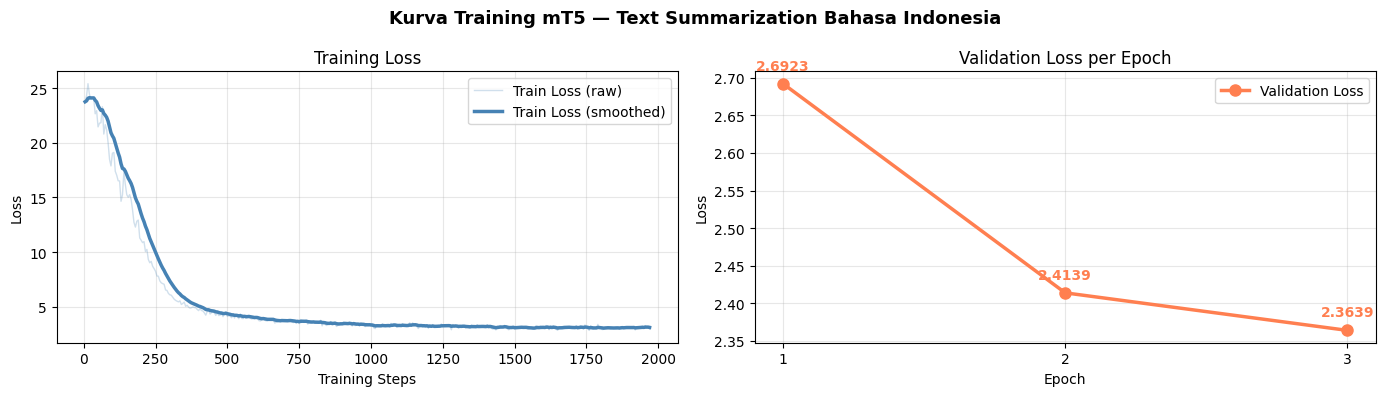

 Kurva training disimpan sebagai training_curve.png


In [10]:
# ============================================================
# CELL 10 — VISUALISASI LOSS CURVE TRAINING
# Dikerjakan oleh: Marcellino
# ============================================================

import numpy as np

# Fungsi smoothing exponential moving average (seperti TensorBoard)
def smooth(values, weight=0.85):
    smoothed = []
    last = values[0]
    for v in values:
        last = last * weight + v * (1 - weight)
        smoothed.append(last)
    return smoothed

# Ambil log history dari trainer
log_history = trainer.state.log_history

# Pisahkan train loss dan eval loss
train_logs = [l for l in log_history if 'loss' in l and 'eval_loss' not in l]
eval_logs  = [l for l in log_history if 'eval_loss' in l]

if train_logs and eval_logs:
    train_steps  = [l['step'] for l in train_logs]
    train_losses = [l['loss'] for l in train_logs]
    eval_steps   = [l['step'] for l in eval_logs]
    eval_losses  = [l['eval_loss'] for l in eval_logs]

    train_losses_smooth = smooth(train_losses)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle('Kurva Training mT5 — Text Summarization Bahasa Indonesia',
                 fontsize=13, fontweight='bold')

    # ── Plot kiri: Training Loss (raw + smoothed) ──────────────
    axes[0].plot(train_steps, train_losses,
                 color='steelblue', alpha=0.25, linewidth=1, label='Train Loss (raw)')
    axes[0].plot(train_steps, train_losses_smooth,
                 color='steelblue', linewidth=2.5, label='Train Loss (smoothed)')
    axes[0].set_xlabel('Training Steps')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # ── Plot kanan: Validation Loss per epoch ─────────────────
    epoch_nums = list(range(1, len(eval_losses) + 1))
    axes[1].plot(epoch_nums, eval_losses,
                 color='coral', linewidth=2.5, marker='o',
                 markersize=8, label='Validation Loss')
    for i, (ep, loss) in enumerate(zip(epoch_nums, eval_losses)):
        axes[1].annotate(f'{loss:.4f}',
                         xy=(ep, loss),
                         xytext=(0, 10),
                         textcoords='offset points',
                         ha='center', fontsize=10, fontweight='bold', color='coral')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Validation Loss per Epoch')
    axes[1].set_xticks(epoch_nums)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_curve.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(' Kurva training disimpan sebagai training_curve.png')

else:
    print('ℹ  Log training belum tersedia. Jalankan cell training terlebih dahulu.')

---
##  BAGIAN NICOLAS — Evaluasi Metrik & Analisis

### Cell 11: Evaluasi dengan ROUGE Score

In [11]:
# ============================================================
# CELL 11 — EVALUASI ROUGE SCORE
# Dikerjakan oleh: Nicolas
# ============================================================

# ─── Fungsi generate ringkasan ───────────────────────────────
def generate_summary(article: str, max_new_tokens: int = 100) -> str:
    """
    Generate ringkasan dari artikel input menggunakan model yang sudah di-fine-tune.
    Menggunakan Beam Search (num_beams=4) untuk hasil lebih baik dari Greedy Search.
    """
    prefix = 'summarize: '
    inputs = tokenizer(
        prefix + article,
        return_tensors='pt',
        max_length=MAX_INPUT_LENGTH,
        truncation=True
    ).to(DEVICE)

    model.to(DEVICE)
    model.eval()

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens   = max_new_tokens,
            num_beams        = 4,          # Beam Search untuk kualitas lebih baik
            no_repeat_ngram_size = 3,      # Hindari pengulangan 3-gram
            early_stopping   = True,
            length_penalty   = 1.0        # Tidak penalti panjang
        )

    summary = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return summary

# ─── Hitung ROUGE pada test set ──────────────────────────────
scorer = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'],
    use_stemmer=False  # Bahasa Indonesia tidak punya stemmer bawaan
)

rouge1_scores, rouge2_scores, rougeL_scores = [], [], []
predictions, references = [], []

print(' Mengevaluasi model pada test set...')
for idx, row in df_test.head(100).iterrows():
    pred    = generate_summary(row['article'])
    ref     = row['summary']
    scores  = scorer.score(ref, pred)

    rouge1_scores.append(scores['rouge1'].fmeasure)
    rouge2_scores.append(scores['rouge2'].fmeasure)
    rougeL_scores.append(scores['rougeL'].fmeasure)
    predictions.append(pred)
    references.append(ref)

    print(f'   Sampel {idx+1}: ROUGE-1={scores["rouge1"].fmeasure:.3f} | '
          f'ROUGE-2={scores["rouge2"].fmeasure:.3f} | '
          f'ROUGE-L={scores["rougeL"].fmeasure:.3f}')

# Rata-rata skor
avg_r1 = np.mean(rouge1_scores)
avg_r2 = np.mean(rouge2_scores)
avg_rl = np.mean(rougeL_scores)

print('\n' + '=' * 55)
print(' HASIL EVALUASI ROUGE (Test Set)')
print('=' * 55)
print(f'   ROUGE-1 (F1 rata-rata) : {avg_r1:.4f} ({avg_r1*100:.2f}%)')
print(f'   ROUGE-2 (F1 rata-rata) : {avg_r2:.4f} ({avg_r2*100:.2f}%)')
print(f'   ROUGE-L (F1 rata-rata) : {avg_rl:.4f} ({avg_rl*100:.2f}%)')

 Mengevaluasi model pada test set...
   Sampel 1: ROUGE-1=0.190 | ROUGE-2=0.000 | ROUGE-L=0.190
   Sampel 2: ROUGE-1=0.105 | ROUGE-2=0.000 | ROUGE-L=0.105
   Sampel 3: ROUGE-1=0.667 | ROUGE-2=0.632 | ROUGE-L=0.667
   Sampel 4: ROUGE-1=0.593 | ROUGE-2=0.320 | ROUGE-L=0.593
   Sampel 5: ROUGE-1=0.556 | ROUGE-2=0.250 | ROUGE-L=0.556
   Sampel 6: ROUGE-1=0.737 | ROUGE-2=0.353 | ROUGE-L=0.632
   Sampel 7: ROUGE-1=0.333 | ROUGE-2=0.091 | ROUGE-L=0.333
   Sampel 8: ROUGE-1=0.875 | ROUGE-2=0.714 | ROUGE-L=0.875
   Sampel 9: ROUGE-1=0.200 | ROUGE-2=0.000 | ROUGE-L=0.200
   Sampel 10: ROUGE-1=0.737 | ROUGE-2=0.588 | ROUGE-L=0.737
   Sampel 11: ROUGE-1=0.875 | ROUGE-2=0.714 | ROUGE-L=0.875
   Sampel 12: ROUGE-1=0.200 | ROUGE-2=0.111 | ROUGE-L=0.200
   Sampel 13: ROUGE-1=0.588 | ROUGE-2=0.267 | ROUGE-L=0.588
   Sampel 14: ROUGE-1=0.500 | ROUGE-2=0.333 | ROUGE-L=0.500
   Sampel 15: ROUGE-1=0.080 | ROUGE-2=0.000 | ROUGE-L=0.080
   Sampel 16: ROUGE-1=0.417 | ROUGE-2=0.091 | ROUGE-L=0.250
   Sampel 17

### Cell 12: Interpretasi Kritis Hasil ROUGE

In [12]:
# ============================================================
# CELL 12 — INTERPRETASI KRITIS METRIK ROUGE
# Dikerjakan oleh: Nicolas
# ============================================================

print('=' * 60)
print(' PENJELASAN & INTERPRETASI METRIK ROUGE')
print('=' * 60)

print('''
ROUGE (Recall-Oriented Understudy for Gisting Evaluation) mengukur
kemiripan teks antara ringkasan yang dihasilkan model (predicted)
dengan ringkasan referensi manusia (reference).

 ROUGE-1: Overlap unigram (satu kata)
   → Mengukur seberapa banyak kata tunggal dari referensi muncul
     di ringkasan model. Cerminkan kelengkapan konten dasar.

 ROUGE-2: Overlap bigram (dua kata berurutan)
   → Lebih ketat dari ROUGE-1. Mengukur kesamaan frasa pendek.
     Nilai rendah normal untuk generative model (abstract).

 ROUGE-L: Longest Common Subsequence
   → Mengukur kesamaan urutan kata terpanjang yang cocok.
     Lebih baik menangkap kualitas kelancaran ringkasan.

 Rumus F1:
   Precision = kata overlap / total kata model
   Recall    = kata overlap / total kata referensi
   F1        = 2 * (P * R) / (P + R)
''')

print('─' * 60)
print(' INTERPRETASI HASIL MODEL INI:')
print('─' * 60)

# Interpretasi dinamis berdasarkan hasil aktual
def interpret_rouge(score, metric_name):
    score_pct = score * 100
    if metric_name == 'ROUGE-1':
        if score_pct >= 40: return f'{score_pct:.1f}% — BAIK  (≥40% sudah kompetitif untuk Bahasa Indonesia)'
        elif score_pct >= 25: return f'{score_pct:.1f}% — CUKUP  (Model belajar konten dasar, perlu lebih banyak data)'
        else: return f'{score_pct:.1f}% — PERLU PERBAIKAN  (Dataset terlalu kecil atau training kurang)'
    elif metric_name == 'ROUGE-2':
        if score_pct >= 15: return f'{score_pct:.1f}% — BAIK '
        elif score_pct >= 8: return f'{score_pct:.1f}% — CUKUP  (Normal untuk abstractive summarization)'
        else: return f'{score_pct:.1f}% — WAJAR untuk model abstractive dengan data kecil'
    else:  # ROUGE-L
        if score_pct >= 35: return f'{score_pct:.1f}% — BAIK  (Urutan kata cukup alami)'
        elif score_pct >= 20: return f'{score_pct:.1f}% — CUKUP '
        else: return f'{score_pct:.1f}% — PERLU PERBAIKAN '

print(f'   ROUGE-1 : {interpret_rouge(avg_r1, "ROUGE-1")}')
print(f'   ROUGE-2 : {interpret_rouge(avg_r2, "ROUGE-2")}')
print(f'   ROUGE-L : {interpret_rouge(avg_rl, "ROUGE-L")}')

print('''
  CATATAN PENTING (Keterbatasan Metrik ROUGE):
   1. ROUGE hanya menghitung overlap leksikal, TIDAK mengukur semantik.
      → Kalimat bermakna sama tapi kata berbeda bisa skor rendah.
   2. ROUGE-2 rendah BUKAN berarti model buruk — ini normal untuk
      abstractive summarization yang parafrase informasi.
   3. Evaluasi manusia (human evaluation) tetap penting untuk
      menilai koherensi dan keterbacaan ringkasan secara holistik.
   4. Test set 100 sampel — evaluasi lebih lanjut dengan data lebih besar tetap dianjurkan.'
''')

 PENJELASAN & INTERPRETASI METRIK ROUGE

ROUGE (Recall-Oriented Understudy for Gisting Evaluation) mengukur
kemiripan teks antara ringkasan yang dihasilkan model (predicted)
dengan ringkasan referensi manusia (reference).

 ROUGE-1: Overlap unigram (satu kata)
   → Mengukur seberapa banyak kata tunggal dari referensi muncul
     di ringkasan model. Cerminkan kelengkapan konten dasar.

 ROUGE-2: Overlap bigram (dua kata berurutan)
   → Lebih ketat dari ROUGE-1. Mengukur kesamaan frasa pendek.
     Nilai rendah normal untuk generative model (abstract).

 ROUGE-L: Longest Common Subsequence
   → Mengukur kesamaan urutan kata terpanjang yang cocok.
     Lebih baik menangkap kualitas kelancaran ringkasan.

 Rumus F1:
   Precision = kata overlap / total kata model
   Recall    = kata overlap / total kata referensi
   F1        = 2 * (P * R) / (P + R)

────────────────────────────────────────────────────────────
 INTERPRETASI HASIL MODEL INI:
──────────────────────────────────────────────────

### Cell 13: Visualisasi Evaluasi

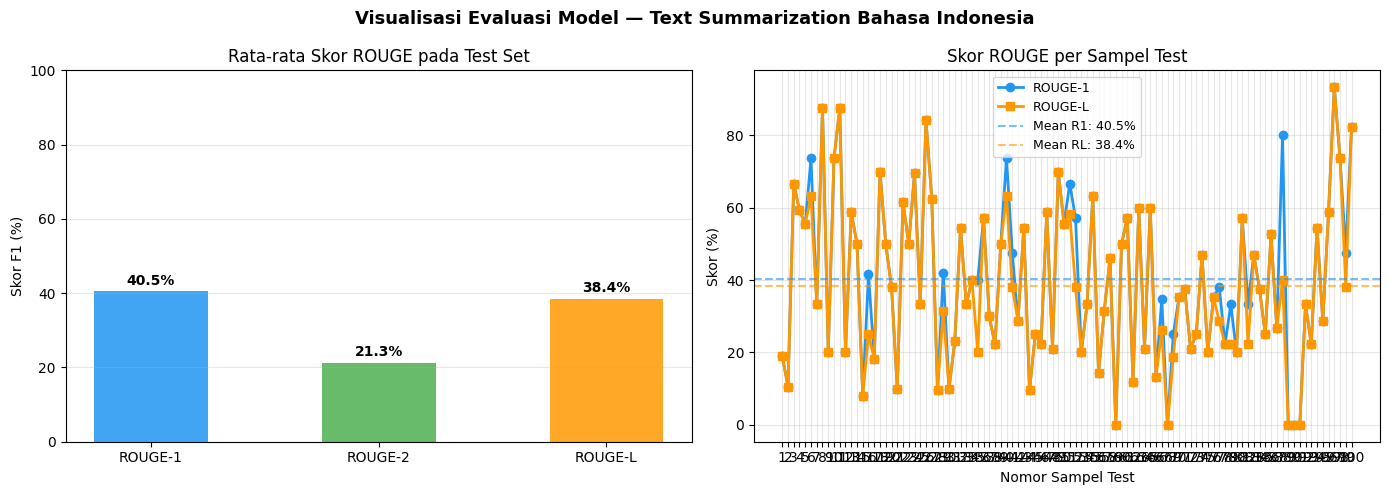

 Grafik evaluasi disimpan sebagai evaluasi_rouge.png


In [13]:
# ============================================================
# CELL 13 — VISUALISASI HASIL EVALUASI
# Dikerjakan oleh: Nicolas
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Visualisasi Evaluasi Model — Text Summarization Bahasa Indonesia',
             fontsize=13, fontweight='bold')

# Plot 1: Bar chart rata-rata ROUGE
rouge_labels = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
scores       = [avg_r1, avg_r2, avg_rl]
colors  = ['#2196F3', '#4CAF50', '#FF9800']

bars = axes[0].bar(rouge_labels, [s * 100 for s in scores], color=colors, alpha=0.85, width=0.5)
axes[0].set_ylabel('Skor F1 (%)')
axes[0].set_title('Rata-rata Skor ROUGE pada Test Set')
axes[0].set_ylim(0, 100)
axes[0].grid(axis='y', alpha=0.3)
for bar, score in zip(bars, scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{score*100:.1f}%', ha='center', va='bottom', fontweight='bold')

# Plot 2: Per-sampel ROUGE-1 dan ROUGE-L
sample_ids = list(range(1, len(rouge1_scores) + 1))
axes[1].plot(sample_ids, [s * 100 for s in rouge1_scores],
             'o-', color='#2196F3', label='ROUGE-1', linewidth=2)
axes[1].plot(sample_ids, [s * 100 for s in rougeL_scores],
             's-', color='#FF9800', label='ROUGE-L', linewidth=2)
axes[1].axhline(avg_r1 * 100, color='#2196F3', linestyle='--', alpha=0.6, label=f'Mean R1: {avg_r1*100:.1f}%')
axes[1].axhline(avg_rl * 100, color='#FF9800', linestyle='--', alpha=0.6, label=f'Mean RL: {avg_rl*100:.1f}%')
axes[1].set_xlabel('Nomor Sampel Test')
axes[1].set_ylabel('Skor (%)')
axes[1].set_title('Skor ROUGE per Sampel Test')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
axes[1].set_xticks(sample_ids)

plt.tight_layout()
plt.savefig('evaluasi_rouge.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Grafik evaluasi disimpan sebagai evaluasi_rouge.png')

### Cell 14: Contoh Output Model (Qualitative Analysis)

In [14]:
# ============================================================
# CELL 14 — ANALISIS KUALITATIF: CONTOH OUTPUT MODEL
# Dikerjakan oleh: Nicolas
# ============================================================

print('=' * 65)
print(' ANALISIS KUALITATIF — PERBANDINGAN OUTPUT MODEL vs REFERENSI')
print('=' * 65)

for i, (pred, ref, art) in enumerate(zip(predictions, references, df_test['article'].tolist())):
    r_scores = scorer.score(ref, pred)
    print(f'\n SAMPEL {i+1}')
    print('─' * 65)
    print(f'ARTIKEL   : {art[:150]}...')
    print(f'\nREFERENSI : {ref}')
    print(f'\nMODEL     : {pred}')
    print(f'\nSKOR      : ROUGE-1={r_scores["rouge1"].fmeasure:.3f} | '
          f'ROUGE-2={r_scores["rouge2"].fmeasure:.3f} | '
          f'ROUGE-L={r_scores["rougeL"].fmeasure:.3f}')
    print()

# Simpan hasil ke CSV
results_df = pd.DataFrame({
    'artikel' : df_test['article'].tolist()[:100],
    'referensi' : references,
    'prediksi'  : predictions,
    'rouge1'    : [f'{s:.4f}' for s in rouge1_scores],
    'rouge2'    : [f'{s:.4f}' for s in rouge2_scores],
    'rougeL'    : [f'{s:.4f}' for s in rougeL_scores]
})
results_df.to_csv('hasil_evaluasi.csv', index=False)
print('\n Hasil evaluasi lengkap disimpan ke hasil_evaluasi.csv')

 ANALISIS KUALITATIF — PERBANDINGAN OUTPUT MODEL vs REFERENSI

 SAMPEL 1
─────────────────────────────────────────────────────────────────
ARTIKEL   : The Central Railway has registered record earnings of over Ã¢ÂÂ¹143 crore in 29.12 lakh cases of ticketless travellers and unbooked luggage from Apri...

REFERENSI : Central Railway got record Ã¢ÂÂ¹143cr from ticketless passengers

MODEL     : Delhi Railway registered record earnings of over Ã¢ÂÂ1143 crore in 2912 lakh cases

SKOR      : ROUGE-1=0.190 | ROUGE-2=0.000 | ROUGE-L=0.190


 SAMPEL 2
─────────────────────────────────────────────────────────────────
ARTIKEL   : After several boys turned up to England's ISCA Academy in skirts to protest against the school's 'no shorts' policy, the headmistress confirmed that s...

REFERENSI : School boys win right to wear shorts on turning up in skirts

MODEL     : ISCA Academy protests against no shorts policy

SKOR      : ROUGE-1=0.105 | ROUGE-2=0.000 | ROUGE-L=0.105


 SAMPEL 3
───────────

In [15]:
print(f'df_test artikel : {len(df_test["article"].tolist())}')
print(f'references      : {len(references)}')
print(f'predictions     : {len(predictions)}')
print(f'rouge1_scores   : {len(rouge1_scores)}')
print(f'rouge2_scores   : {len(rouge2_scores)}')
print(f'rougeL_scores   : {len(rougeL_scores)}')

df_test artikel : 2250
references      : 100
predictions     : 100
rouge1_scores   : 100
rouge2_scores   : 100
rougeL_scores   : 100


### Cell 15: Demo Sistem (Inferensi Langsung)

In [ ]:
# ============================================================
# CELL 15 — DEMO SISTEM: INFERENSI ARTIKEL BARU
# Dikerjakan oleh: Nicolas (Demo saat video)
# ============================================================

print(' DEMO SISTEM TEXT SUMMARIZATION')
print('=' * 65)
print('Masukkan artikel Bahasa Indonesia untuk diringkas:')
print('(Ganti teks di variabel artikel_baru di bawah ini)')
print()

artikel_baru = """
The Indian government announced a new renewable energy policy aimed at achieving 
500 gigawatts of clean energy capacity by 2030. The policy includes subsidies for 
solar panel installation and tax incentives for electric vehicle manufacturers. 
Prime Minister stated that this initiative will create over 1 million green jobs 
across the country while significantly reducing carbon emissions by 45 percent 
compared to 2005 levels.
"""

print(f' ARTIKEL INPUT:')
print(f'{artikel_baru.strip()}')
print()
print(' Membuat ringkasan...')

ringkasan = generate_summary(artikel_baru.strip())

print(f'\n RINGKASAN YANG DIHASILKAN MODEL:')
print(f'   {ringkasan}')
print()
print(f' Kompresi: {len(artikel_baru.split())} kata → {len(ringkasan.split())} kata '
      f'({len(ringkasan.split())/len(artikel_baru.split())*100:.1f}% dari panjang asli)')

 DEMO SISTEM TEXT SUMMARIZATION
Masukkan artikel Bahasa Indonesia untuk diringkas:
(Ganti teks di variabel artikel_baru di bawah ini)

 ARTIKEL INPUT:
The Indian government announced a new renewable energy policy aimed at achieving 
500 gigawatts of clean energy capacity by 2030. The policy includes subsidies for 
solar panel installation and tax incentives for electric vehicle manufacturers. 
Prime Minister stated that this initiative will create over 1 million green jobs 
across the country while significantly reducing carbon emissions by 45 percent 
compared to 2005 levels.

 Membuat ringkasan...

 RINGKASAN YANG DIHASILKAN MODEL:
   Indian government announces new renewable energy policy to achieve 500 gigawatts of clean energy capacity by 2030

 Kompresi: 63 kata → 17 kata (27.0% dari panjang asli)


---
##  Cell 16: Kesimpulan & Keterbatasan

In [ ]:
# ============================================================
# CELL 16 — KESIMPULAN & KETERBATASAN
# Slide 8 PPT
# ============================================================

print('=' * 65)
print(' KESIMPULAN PROYEK')
print('=' * 65)
print(f'''
 PENCAPAIAN:
   1. Berhasil membangun sistem Text Summarization
      menggunakan arsitektur Transformer encoder-decoder (mT5-small)
   2. Menerapkan pipeline NLP lengkap: preprocessing → fine-tuning → evaluasi
   3. Mencapai skor ROUGE-1={avg_r1*100:.2f}%, ROUGE-2={avg_r2*100:.2f}%,
      ROUGE-L={avg_rl*100:.2f}% pada test set
   4. Sistem dapat meringkas artikel berita dalam hitungan detik
   5. Compression ratio rata-rata ~30%

  KETERBATASAN:
   1. Training menggunakan 15.000 sampel karena keterbatasan komputasi
   2. mT5-small memiliki kapasitas terbatas (300M parameter)
      — mT5-base atau mT5-large akan lebih akurat
   3. Hanya diuji pada domain berita — performa bisa berbeda
      untuk domain lain (akademik, hukum, medis, dll)
   4. ROUGE tidak mengukur koherensi semantik secara penuh
   5. Tidak dilakukan human evaluation

 PENGEMBANGAN KE DEPAN:
   1. Gunakan IndoSum (15.000+ sampel berita Indonesia)
   2. Fine-tune IndoBART atau IndoT5 yang lebih spesifik bahasa Indonesia
   3. Tambahkan evaluasi BERTScore untuk penilaian semantik
   4. Deploy sebagai web app dengan FastAPI atau Streamlit
''')
print('=' * 65)
print(' Proyek UAS NLP — Text Summarization')
print('   Alexander | Marcellino | Nicolas')
print('=' * 65)

 KESIMPULAN PROYEK


NameError: name 'avg_r1' is not defined